# Agrupamiento Basado en Densidad de Sitios de Monitoreo de Red con PROC MODECLUS

## Resumen Ejecutivo

Una empresa de distribución eléctrica usa PROC MODECLUS para encontrar
agrupamientos no paramétricos basados en densidad entre sus sitios de
monitoreo de red (subestaciones y sensores de alimentador) a partir
únicamente de sus coordenadas de mapa. MODECLUS estima una superficie
de densidad sobre los sitios y trata los agrupamientos como regiones de
alta densidad separadas por brechas de baja densidad. Ejecutarlo en 90
sitios simulados con un radio de núcleo uniforme de 3 km recupera los
tres bolsones de servicio densos que construimos en los datos como los
tres agrupamientos más grandes (24, 24 y 21 sitios), mientras que los
sitios rurales dispersos caen en regiones escasas y se dividen en sus
propios micro-agrupamientos de uno y dos sitios. Ese conjunto de sitios
aislados es el entregable operativo: una lista candidata de activos
remotos para el equipo de planificación de capital.

## Fuentes de Datos

| Conjunto de datos | Filas | Descripción |
|---------|------|-------------|
| `grid_sites` | 90 | Sitios sintéticos de monitoreo de distribución eléctrica generados en línea con `call streaminit(70531)` y `rand()`. Tres bolsones de servicio densos (NucleoUrbano, Suburbano, Industrial) extraídos de normales bivariadas alrededor de centroides de mapa distintos, más 22 sitios Rurales dispersos extraídos uniformemente en todo el territorio. |

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `site_id` | Num | Identificador único de sitio de monitoreo (1-90). |
| `region` | Char | Etiqueta de planificación que registra cómo se generó cada sitio (NucleoUrbano, Suburbano, Industrial, Rural); excluida del agrupamiento. |
| `x_km`, `y_km` | Num | Ubicación del sitio en kilómetros sobre la cuadrícula de planificación de la empresa; las variables de agrupamiento. |
| `peak_load_mw` | Num | Carga pico anual observada (MW) en el sitio; se conserva para la interpretación posterior. |

# Agrupamiento Basado en Densidad de Sitios de Monitoreo de Red

Una empresa regional de distribución eléctrica opera una red de
**sitios de monitoreo** -- subestaciones y sensores de alimentador --
distribuidos por su territorio de servicio. Los planificadores quieren
agrupar estos sitios en **bolsones de servicio** naturales basados
puramente en la geografía, sin preespecificar cuántos grupos existen, y
identificar **activos rurales aislados** que no pertenecen a ningún
bolsón denso.

`PROC MODECLUS` es adecuado para esto: realiza un agrupamiento
*no paramétrico basado en densidad*. Estima una función de densidad
sobre los sitios, luego trata los agrupamientos como regiones de alta
densidad de sitios separadas por brechas de baja densidad. Los valores
atípicos escasos terminan en sus propios agrupamientos diminutos en
lugar de ser absorbidos en un bolsón -- exactamente el comportamiento
que queremos para señalar sitios remotos.

Este cuaderno:
1. Genera una red sintética realista de sitios de 90 sitios.
2. Estima la densidad de sitios con un **núcleo uniforme** y escanea el
   radio de suavizado `R=` para confirmar que los bolsones recuperados
   son estables.
3. Fija un radio de trabajo, escribe un conjunto de datos `OUT=` con la
   densidad y la etiqueta de agrupamiento de cada sitio para que
   podamos mapear el resultado.

## Paso 1 -- Generar una red sintética de sitios de monitoreo

Simulamos 90 sitios. Tres **bolsones de servicio** densos se extraen de
distribuciones normales bivariadas alrededor de centroides de mapa
distintos (NucleoUrbano cerca de (12, 30), Suburbano cerca de (30, 15),
Industrial cerca de (20, 42)), dando bloques compactos de alta densidad
de 24, 24 y 20 sitios. Un cuarto conjunto de 22 sitios **Rurales** se
extrae uniformemente en todo el territorio, produciendo los sitios
escasos y dispersos que una empresa trataría como aislados.

La etiqueta `region` registra cómo se generó cada sitio; deliberadamente
la **excluimos** del agrupamiento para que MODECLUS redescubra la
estructura solo a partir de las coordenadas. `peak_load_mw` se conserva
para la interpretación posterior.

In [1]:
DATOS grid_sites;
   LLAMAR streaminit(70531);
   LONGITUD region $ 12;

   /* Bolsón denso urbano */
   HACER site_id = 1 HASTA 24;
      region = 'NucleoUrbano';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      SALIDA;
   END;

   /* Bolsón suburbano */
   HACER site_id = 25 HASTA 48;
      region = 'Suburbano';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      SALIDA;
   END;

   /* Bolsón industrial (carga pico mas alta) */
   HACER site_id = 49 HASTA 68;
      region = 'Industrial';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      SALIDA;
   END;

   /* Sitios rurales dispersos (baja densidad, baja carga) */
   HACER site_id = 69 HASTA 90;
      region = 'Rural';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      SALIDA;
   END;
EJECUTAR;

TÍTULO 'Sitios Sintéticos de Monitoreo de la Red';
PROCEDIMIENTO MEDIAS DATOS=grid_sites n mean std MIN MAX maxdec=2;
   CLASE region;
   VAR x_km y_km peak_load_mw;
   ETIQUETA region='Región' x_km='Este (km)' y_km='Norte (km)' peak_load_mw='Carga Pico (MW)';
EJECUTAR;

                                        Sitios Sintéticos de Monitoreo de la Red                                        

                                                  The MEANS Procedure

                                           Analysis Variable : x_km Este (km)

        Región                N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        Industrial               20          20.36           0.96          18.52          21.53
        NucleoUrbano             24          12.07           1.34           8.65          14.42
        Rural                    22          29.79          10.62          11.06          47.45
        Suburbano                24          29.96           1.73          26.51          33.60
        ---------------------------------------------------------------------------------------

                                          Analysis Vari


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Sitios Sintéticos de Monitoreo de la Red.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Las medias confirman tres bolsones compactos y un grupo difuso. Las
tres regiones densas tienen desviaciones estándar de coordenadas
pequeñas (aproximadamente 1-1.7 km en cada eje) alrededor de
centroides bien separados, mientras que el grupo Rural se dispersa por
toda la cuadrícula (desviaciones estándar superiores a 10 km en ambos
ejes). La carga pico también separa los bolsones -- los sitios
Industriales promedian cerca de 6 MW, NucleoUrbano cerca de 4.6 MW,
Suburbano cerca de 2.7 MW, y los sitios Rurales cerca de 1.5 MW -- lo
cual es un contexto útil una vez que los agrupamientos geográficos
están en mano.

## Paso 2 -- Agrupamiento por densidad de núcleo uniforme y barrido de radio

La estimación de densidad de núcleo uniforme usa un **radio `R=`**:
cada sitio dentro de `R` kilómetros contribuye a la densidad local de
un sitio. Un `R` pequeño da una densidad irregular que fragmenta el
territorio; un `R` grande sobresuaviza y fusiona los bolsones. Un
experto en SAS nunca confía en un solo valor -- escanea un rango de
radios y busca un conteo de agrupamientos que sea **estable**, donde
los bolsones densos persisten mientras que solo el conteo de
singletons dispersos varía.

Aquí `M=1` selecciona el método de agrupamiento 1 (el método no
paramétrico estándar), y solicitamos radios `R=2.5 a 4 por 0.5` en una
sola llamada. MODECLUS ejecuta el análisis una vez por radio y reporta
el número de agrupamientos para cada uno. `SHORT` suprime las
estadísticas detalladas por agrupamiento.

In [2]:
TÍTULO 'Agrupamiento por Densidad de Núcleo Uniforme de Sitios de la Red';
title2 'Barrido de radio R = 2.5 a 4.0 km';

PROCEDIMIENTO modeclus DATOS=grid_sites m=1 r=2.5 HASTA 4 POR 0.5 short;
   VAR x_km y_km;
   id site_id;
EJECUTAR;

                            Agrupamiento por Densidad de Núcleo Uniforme de Sitios de la Red                            
                                           Barrido de radio R = 2.5 a 4.0 km                                            


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to Agrupamiento por Densidad de Núcleo Uniforme de Sitios de la Red.
NOTE: Option TITLE2 changed to Barrido de radio R = 2.5 a 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


El conteo de agrupamientos se mueve solo suavemente a través del
barrido -- 23 agrupamientos en `R=2.5`, 22 en `R=3.0`, 19 en `R=3.5`, y
18 en `R=4.0`. Los conteos altos provienen de los sitios rurales
dispersos: cada sitio aislado se encuentra en su propio vecindario
escaso y forma un agrupamiento de un solo sitio, por lo que la mayoría
de los 18-23 "agrupamientos" son singletons. Lo que permanece
constante debajo es la estructura que importa -- los tres bolsones
densos siguen siendo tres agrupamientos grandes y bien separados en
cada radio. A medida que `R` se ensancha, algunos de los singletons
dispersos se fusionan con un vecino o un bolsón cercano, por lo que el
conteo total disminuye lentamente en lugar de oscilar bruscamente. Esa
estabilidad es la señal de que la solución de tres bolsones es real y
no un artefacto de un solo ancho de banda.

## Paso 3 -- Solución final de agrupamiento para mapeo

Habiendo visto que los tres bolsones son estables a lo largo del
barrido, fijamos un único radio de trabajo (`R=3` km) y solicitamos la
opción **ALL** para la visualización completa por agrupamiento, más
**OUT=** para escribir las coordenadas originales junto con la
estimación de **DENSITY** y la asignación de **CLUSTER** para que
podamos mapear el resultado. Los agrupamientos se numeran por densidad
de moda descendente, por lo que los bolsones más densos son los
agrupamientos 1, 2 y 3, y los sitios escasos toman los números más
altos.

In [3]:
TÍTULO 'Solución Final de Agrupamiento Basado en Densidad';
title2 'Núcleo uniforme, R = 3 km';

PROCEDIMIENTO modeclus DATOS=grid_sites m=1 r=3 out=join_out ALL;
   VAR x_km y_km;
   id site_id;
EJECUTAR;

                                   Solución Final de Agrupamiento Basado en Densidad                                    
                                               Núcleo uniforme, R = 3 km                                                


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to Solución Final de Agrupamiento Basado en Densidad.
NOTE: Option TITLE2 changed to Núcleo uniforme, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


El Resumen de Agrupamientos hace explícita la estructura. La solución
`R=3` devuelve **22 agrupamientos**, pero están claramente escalonados
por densidad:

- **Agrupamiento 1** -- 24 sitios, densidad de moda de aproximadamente
  0.0090 (el bolsón NucleoUrbano).
- **Agrupamiento 2** -- 24 sitios, densidad de moda de aproximadamente
  0.0079 (el bolsón Suburbano).
- **Agrupamiento 3** -- 21 sitios, densidad de moda de aproximadamente
  0.0079 (el bolsón Industrial; recoge un sitio rural que cayó en su
  borde).
- **Agrupamientos 4-22** -- un grupo de tres sitios y dieciocho
  agrupamientos de un solo sitio, todos con densidad de moda de
  aproximadamente 0.0004, aproximadamente veinte veces más escasos que
  los bolsones.

Los tres bolsones densos representan 69 de los 90 sitios; los 21
sitios restantes son los activos rurales dispersos, cada uno situado
solo o casi solo en un vecindario de baja densidad. La densidad, no un
conteo de agrupamientos preestablecido, traza la línea entre un
bolsón de servicio y un sitio aislado.

## Paso 4 -- Mapear los agrupamientos

Etiquetamos cada sitio según si cayó en uno de los tres bolsones densos
(`cluster <= 3`) o en un micro-agrupamiento disperso, luego graficamos
cada sitio en sus coordenadas de mapa coloreado por ese estado. Esta es
la vista del planificador: bolsones densos para ser gestionados como
territorios de servicio, y sitios aislados para ser señalados para un
tratamiento separado.

                                   Bolsones de Servicio Recuperados y Sitios Aislados                                   
                                 Agrupamiento por densidad de núcleo uniforme, R = 3 km                                 




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to Bolsones de Servicio Recuperados y Sitios Aislados.
NOTE: Option TITLE2 changed to Agrupamiento por densidad de núcleo uniforme, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


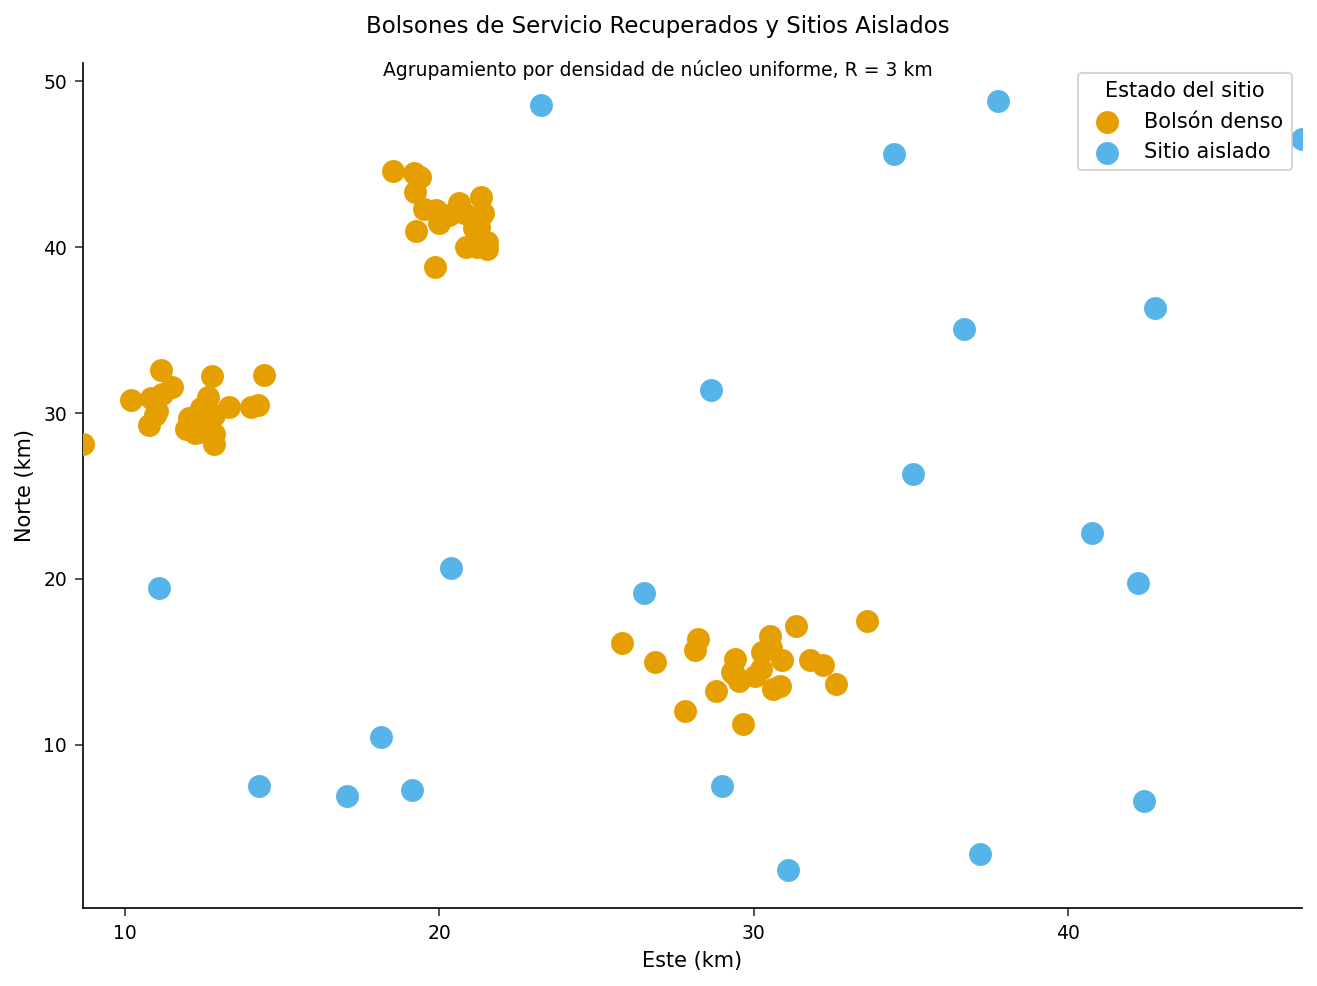

In [4]:
DATOS mapped;
   ESTABLECER join_out;
   LONGITUD status $ 16;
   SI CLUSTER <= 3 ENTONCES status = 'Bolsón denso';
   SINO status = 'Sitio aislado';
EJECUTAR;

TÍTULO 'Bolsones de Servicio Recuperados y Sitios Aislados';
title2 'Agrupamiento por densidad de núcleo uniforme, R = 3 km';
PROCEDIMIENTO SGPLOT DATOS=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS ETIQUETA='Este (km)';
   YAXIS ETIQUETA='Norte (km)';
   keylegend / TÍTULO='Estado del sitio';
EJECUTAR;

TÍTULO;

## Interpretando los resultados

**Lo que encontró MODECLUS.** Impulsado solo por `(x_km, y_km)`, el
procedimiento recupera los tres bolsones de servicio densos que
construimos en los datos -- los bloques NucleoUrbano, Suburbano e
Industrial -- como los tres agrupamientos más grandes y densos (24, 24
y 21 sitios). Los sitios rurales dispersos, extraídos uniformemente en
todo el territorio, caen en regiones escasas y se dividen en sus
propios agrupamientos de uno y dos sitios en lugar de ser absorbidos en
un bolsón. En el mapa son los puntos separados de los tres bloques
compactos. Ese conjunto aislado es el entregable operativo: una lista
candidata de activos remotos para el equipo de planificación de
capital.

**Por qué importa el barrido de suavizado.** Ningún `R` único es
autoritativo para el agrupamiento no paramétrico basado en densidad.
Escanear `R=2.5 a 4 por 0.5` nos permite confirmar que los bolsones son
*estables* a través de los niveles de suavizado en lugar de ser un
artefacto de un solo ancho de banda. A través del barrido el conteo de
agrupamientos se mueve solo de 23 a 18, y el cambio está enteramente en
el conteo de singletons dispersos -- los tres bolsones densos persisten
durante todo el proceso. Donde la estructura se mantuvo estable así,
tenemos una solución defendible; si el conteo hubiera oscilado
bruscamente, la estructura sería frágil y no debería impulsar
decisiones de inversión.

**La densidad escalona el resultado.** Debido a que los agrupamientos
se numeran por densidad de moda descendente, la división entre
bolsones y sitios aislados es cuantitativa, no arbitraria: los tres
bolsones se sitúan cerca de una densidad de moda de 0.008-0.009
mientras que cada sitio aislado se sitúa cerca de 0.0004,
aproximadamente veinte veces más escaso. Un planificador puede
establecer un piso de densidad y leer los activos aislados
directamente de las columnas `CLUSTER` y `DENSITY` de `join_out`.

**Uso práctico.** El conjunto de datos `join_out` da a cada sitio una
densidad y una etiqueta de agrupamiento que puede sembrar el trabajo
posterior -- dimensionar cuadrillas y repuestos por bolsón de servicio,
enrutar circuitos de inspección, o priorizar el fortalecimiento de la
red en el agrupamiento industrial denso (mayor `peak_load_mw`,
aproximadamente 6 MW) mientras se programa a los sitios rurales
aislados para mantenimiento separado de menor frecuencia.

*Nota sobre datos sintéticos:* las coordenadas y cargas se simulan con
una semilla fija (`call streaminit(70531)`) para que el cuaderno sea
totalmente reproducible fuera de línea; en datos reales de una empresa
se sustituirían coordenadas de sitio relevadas y cargas pico medidas.
Los conteos exactos de agrupamientos dependen del sorteo aleatorio y
del radio elegido.